# Rozszerzenie GPU: pełny fine-tuning i analiza warstw głębokich

Eksperyment fine-tuningu modelu VGG16 z wagami pretrained ImageNet na zbiorze CIFAR-10.

Celem eksperymentu jest porównanie kilku strategii dostrajania modelu:

1. model pretrained przed fine-tuningiem
2. trenowanie samego klasyfikatora
3. fine-tuning ostatnich warstw konwolucyjnych
4. pełny fine-tuning całego modelu

Na końcu dokonujemy analizy warstw głębokich przez wizualizację feature maps.

In [2]:
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
import adom_library as adom
import experiments_utils as eu

adom.show_device()


cuda


## Parametry eksperymentu

Parametr `DEEP_LAYER_START_INDEX` jest używany przy częściowym fine-tuningu. W przypadku VGG16 indeks 24 oznacza początek ostatniego, a zarazem najgłębszego bloku konwolucyjnego VGG16 (patrz `adom.show_model_layers` w poniższych komórkach).

In [2]:
EPOCHS = 3
BATCH_SIZE = 64
TRAIN_LIMIT = None # 10000
TEST_LIMIT = None # 2000

MODEL_TYPE = "VGG16"
CLASSES_COUNT = 10

DEEP_LAYER_START_INDEX = 24

FEATURE_MAP_LAYERS = [0, 5, 10, 17, 24, 28]

## Wczytanie CIFAR-10

Biblioteka używa transformacji zgodnej z ImageNet: resize do 256, crop 224 oraz normalizacja mean/std ImageNet (`transform` w `adom_library`).

In [3]:
train_dataset_full = adom.get_CIFAR10_dataset(train_dataset=True)
test_dataset_full = adom.get_CIFAR10_dataset(train_dataset=False)

classes = train_dataset_full.classes

if TRAIN_LIMIT is not None:
    train_dataset = Subset(train_dataset_full, range(TRAIN_LIMIT))
    train_dataset.classes = train_dataset_full.classes
else:
    train_dataset = train_dataset_full

if TEST_LIMIT is not None:
    test_dataset = Subset(test_dataset_full, range(TEST_LIMIT))
    test_dataset.classes = test_dataset_full.classes
else:
    test_dataset = test_dataset_full

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Liczba klas:", len(classes))
print("Klasy:", classes)
print("Liczba obrazów treningowych:", len(train_dataset))
print("Liczba obrazów testowych:", len(test_dataset))

Files already downloaded and verified


d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Liczba klas: 10
Klasy: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Liczba obrazów treningowych: 50000
Liczba obrazów testowych: 10000


## Sprawdzenie warstw VGG16

Indeksy warstw `model.features` wymagane do interpretacji fine-tuningu ostatnich warstw.

In [4]:
example_model = adom.get_vgg16_with_weights_for_cifar10(num_classes=CLASSES_COUNT)
adom.show_model_layers(example_model, only_features=True)

=== model.features ===
0: Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
1: ReLU(inplace=True)
2: Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
3: ReLU(inplace=True)
4: MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
5: Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
6: ReLU(inplace=True)
7: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
8: ReLU(inplace=True)
9: MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
10: Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
11: ReLU(inplace=True)
12: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
13: ReLU(inplace=True)
14: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
15: ReLU(inplace=True)
16: MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
17: Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
18: ReLU(inplace=Tr

## Funkcja uruchamiająca pojedynczy wariant eksperymentu

In [5]:
def run_finetuning_variant(variant_name, setup_fn, epochs=EPOCHS):
    print("=" * 80)
    print("Wariant:", variant_name)
    print("=" * 80)

    model = adom.get_vgg16_with_weights_for_cifar10(num_classes=CLASSES_COUNT)
    model = model.to(adom.DEVICE)

    setup_fn(model)

    trainable_params = adom.count_model_params(model)
    print("Liczba trenowanych parametrów:", trainable_params)

    optimizer = adom.get_optimizer_for_model_unfreeze_layers(
        model=model,
        optimizer_name="Adam",
        lr=0.00001,
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    start_time = time.time()
    model = adom.train_model(
        model=model,
        train_loader=train_loader,
        optimizer=optimizer,
        epochs=epochs,
        with_output=True,
    )
    training_time = time.time() - start_time

    if torch.cuda.is_available():
        peak_gpu_memory_mb = torch.cuda.max_memory_allocated() / 1024 / 1024
    else:
        peak_gpu_memory_mb = None

    evaluation = adom.evaluate_model_on_loader(
        model=model,
        data_loader=test_loader,
        classes=classes,
    )

    print("Test accuracy:", evaluation["accuracy_percent"])
    print("Test loss:", evaluation["avg_loss"])
    print("Training time:", training_time)
    print("Peak GPU memory MB:", peak_gpu_memory_mb)

    return {
        "variant": variant_name,
        "model": model,
        "trainable_params": trainable_params,
        "test_accuracy_percent": evaluation["accuracy_percent"],
        "test_loss": evaluation["avg_loss"],
        "training_time_seconds": training_time,
        "peak_gpu_memory_mb": peak_gpu_memory_mb,
        "evaluation": evaluation,
    }

## Model pretrained przed fine-tuningiem

Najpierw sprawdzamy VGG16 z wagami ImageNet po samej podmianie klasyfikatora na 10 klas. Wynik będzie niski, bo ostatnia warstwa jest losowo zainicjalizowana i nie była jeszcze trenowana na CIFAR-10.

In [6]:
baseline_model = adom.get_vgg16_with_weights_for_cifar10(
    num_classes=CLASSES_COUNT)
baseline_model = baseline_model.to(adom.DEVICE)

baseline_evaluation = adom.evaluate_model_on_loader(
    model=baseline_model,
    data_loader=test_loader,
    classes=classes,
)

baseline_result = {
    "variant": "pretrained_vgg16_without_finetuning",
    "model": baseline_model,
    "trainable_params": adom.count_model_params(baseline_model),
    "test_accuracy_percent": baseline_evaluation["accuracy_percent"],
    "test_loss": baseline_evaluation["avg_loss"],
    "training_time_seconds": 0,
    "peak_gpu_memory_mb": None,
    "evaluation": baseline_evaluation,
}

print(baseline_evaluation)

{'accuracy_percent': 6.85, 'avg_loss': 2.3516466313866293, 'correct': 685, 'total': 10000, 'per_class_accuracy': {'airplane': 0.052, 'automobile': 0.317, 'bird': 0.007, 'cat': 0.011, 'deer': 0.007, 'dog': 0.004, 'frog': 0.154, 'horse': 0.002, 'ship': 0.015, 'truck': 0.116}, 'per_class_correct': {'airplane': 52, 'automobile': 317, 'bird': 7, 'cat': 11, 'deer': 7, 'dog': 4, 'frog': 154, 'horse': 2, 'ship': 15, 'truck': 116}, 'per_class_total': {'airplane': 1000, 'automobile': 1000, 'bird': 1000, 'cat': 1000, 'deer': 1000, 'dog': 1000, 'frog': 1000, 'horse': 1000, 'ship': 1000, 'truck': 1000}}


## Wariant 1: trenowanie samego klasyfikatora

W tym wariancie zamrażamy część konwolucyjną VGG16 i trenujemy jedynie klasyfikator. To sprawdza, czy cechy nauczone na ImageNet są wystarczająco użyteczne dla CIFAR-10.

In [7]:
def setup_classifier_only(model):
    adom.freeze_backbone(model, MODEL_TYPE)

classifier_only_result = run_finetuning_variant(
    variant_name="classifier_only",
    setup_fn=setup_classifier_only,
)

Wariant: classifier_only
Liczba trenowanych parametrów: 119586826
Training VGG for 3 epochs...
Epoch 1, Loss: 0.5968, Acc: 80.49%, Time: 120.87s
Epoch 2, Loss: 0.2866, Acc: 90.55%, Time: 120.68s
Epoch 3, Loss: 0.1659, Acc: 95.24%, Time: 121.09s
Total training time: 362.65s
Test accuracy: 87.87
Test loss: 0.36085510505422663
Training time: 362.6453595161438
Peak GPU memory MB: 4343.9130859375


## Wariant 2: fine-tuning ostatnich warstw konwolucyjnych z klasyfikatorem

Odmrażamy ostatnie warstwy konwolucyjne i trenujemy je razem z klasyfikatorem. To prosty wariant częściowego fine-tuningu głębokich warstw.

In [8]:
def setup_last_layers(model):
    adom.freeze_backbone(model, MODEL_TYPE)
    adom.unfreeze_last_layers(model, MODEL_TYPE)

last_layers_result = run_finetuning_variant(
    variant_name="last_layers_finetuning",
    setup_fn=setup_last_layers,
)

Wariant: last_layers_finetuning
Liczba trenowanych parametrów: 121946634
Training VGG for 3 epochs...
Epoch 1, Loss: 0.5545, Acc: 81.62%, Time: 124.81s
Epoch 2, Loss: 0.2645, Acc: 91.10%, Time: 122.16s
Epoch 3, Loss: 0.1500, Acc: 95.44%, Time: 122.62s
Total training time: 369.59s
Test accuracy: 88.23
Test loss: 0.3448349082261134
Training time: 369.594496011734
Peak GPU memory MB: 5330.92578125


## Wariant 3: pełny fine-tuning całego modelu

Odmrażamy wszystkie parametry. Jest to najpełniejsza forma fine-tuningu, ale też najbardziej kosztowna pamięciowo i obliczeniowo.

In [9]:
def setup_full_finetuning(model):
    adom.unfreeze_all(model)

full_finetuning_result = run_finetuning_variant(
    variant_name="full_finetuning",
    setup_fn=setup_full_finetuning,
)

Wariant: full_finetuning
Liczba trenowanych parametrów: 134301514
Training VGG for 3 epochs...
Epoch 1, Loss: 0.4481, Acc: 84.64%, Time: 1368.08s
Epoch 2, Loss: 0.1573, Acc: 94.70%, Time: 1373.70s
Epoch 3, Loss: 0.0496, Acc: 98.51%, Time: 1374.32s
Total training time: 4116.10s
Test accuracy: 91.65
Test loss: 0.28087018839540373
Training time: 4116.104956150055
Peak GPU memory MB: 9111.751953125


## Zapisanie wyników

In [10]:
adom.save_model(classifier_only_result["model"], "finetuning-classifier_only_model", classes=classes)
adom.save_model(last_layers_result["model"], "finetuning-last_layers_model", classes=classes)
adom.save_model(full_finetuning_result["model"], "finetuning-full_model", classes=classes)

## Zestawienie wyników

Porównujemy jakość klasyfikacji, liczbę trenowanych parametrów, czas treningu oraz użycie pamięci GPU.

In [ ]:
results = [
    baseline_result,
    classifier_only_result,
    last_layers_result,
    full_finetuning_result,
]

summary_df = pd.DataFrame([
    {
        "variant": result["variant"],
        "trainable_params": result["trainable_params"],
        "test_accuracy_percent": result["test_accuracy_percent"],
        "test_loss": result["test_loss"],
        "training_time_seconds": result["training_time_seconds"],
        "peak_gpu_memory_mb": result["peak_gpu_memory_mb"],
    }
    for result in results
])

eu.export_to_csv(summary_df, "finetuning_summary.csv")

summary_df

,variant,trainable_params,test_accuracy_percent,test_loss,training_time_seconds,peak_gpu_memory_mb
0,pretrained_vgg16_without_finetuning,134301514,6.85,2.351647,0.000000,NaN
1,classifier_only,119586826,87.87,0.360855,362.645360,4343.913086
2,last_layers_finetuning,121946634,88.23,0.344835,369.594496,5330.925781
3,full_finetuning,134301514,91.65,0.280870,4116.104956,9111.751953


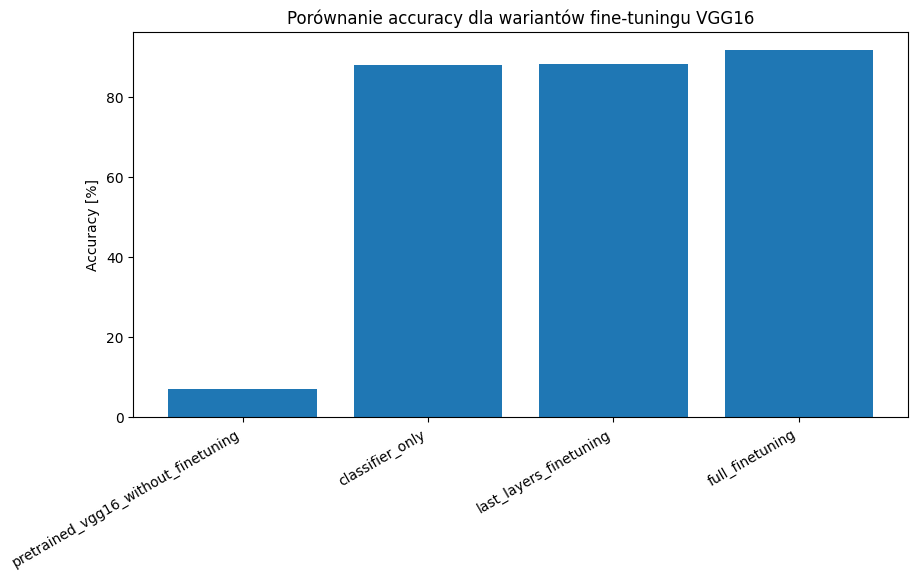

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(summary_df["variant"], summary_df["test_accuracy_percent"])
plt.title("Porównanie accuracy dla wariantów fine-tuningu VGG16")
plt.ylabel("Accuracy [%]")
plt.xticks(rotation=30, ha="right")
plt.show()

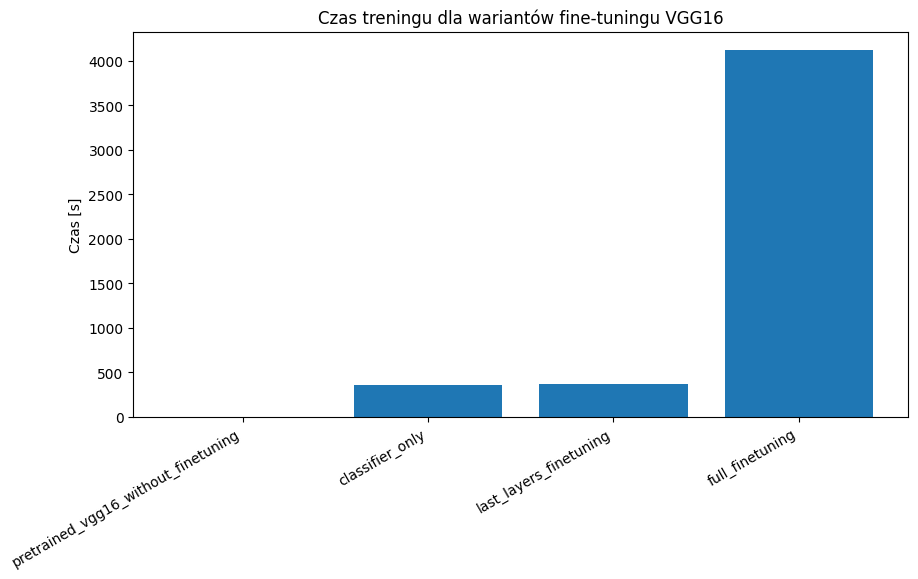

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(summary_df["variant"], summary_df["training_time_seconds"])
plt.title("Czas treningu dla wariantów fine-tuningu VGG16")
plt.ylabel("Czas [s]")
plt.xticks(rotation=30, ha="right")
plt.show()

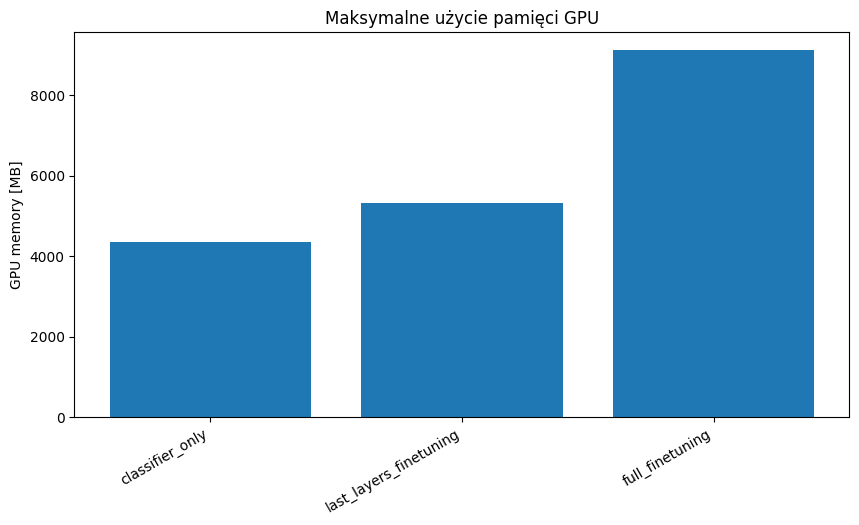

In [15]:
if summary_df["peak_gpu_memory_mb"].notna().any():
    plt.figure(figsize=(10, 5))
    plt.bar(summary_df["variant"], summary_df["peak_gpu_memory_mb"])
    plt.title("Maksymalne użycie pamięci GPU")
    plt.ylabel("GPU memory [MB]")
    plt.xticks(rotation=30, ha="right")
    plt.show()
else:
    print("Brak danych GPU memory, ponieważ CUDA nie jest dostępna.")

## Analiza warstw głębokich (przez feature maps)

Poniżej porównujemy mapy cech dla tego samego obrazu testowego:

1. VGG16 pretrained przed fine-tuningiem,
2. VGG16 po trenowaniu samego klasyfikatora,
3. VGG16 po fine-tuningu ostatnich warstw,
4. VGG16 po pełnym fine-tuningu.

Wczesne warstwy zwykle pokazują krawędzie i proste tekstury, natomiast głębokie warstwy zawierają bardziej abstrakcyjne reprezentacje.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831376].


Prawdziwa klasa: ship


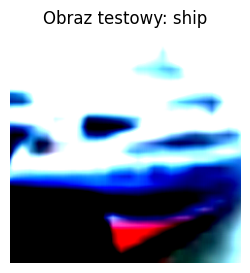

In [16]:
image_tensor, label = test_dataset[1]
print("Prawdziwa klasa:", classes[label])

plt.figure(figsize=(3, 3))
plt.imshow(image_tensor.permute(1, 2, 0).detach().cpu())
plt.title(f"Obraz testowy: {classes[label]}")
plt.axis("off")
plt.show()

Pretrained VGG16 bez fine-tuningu


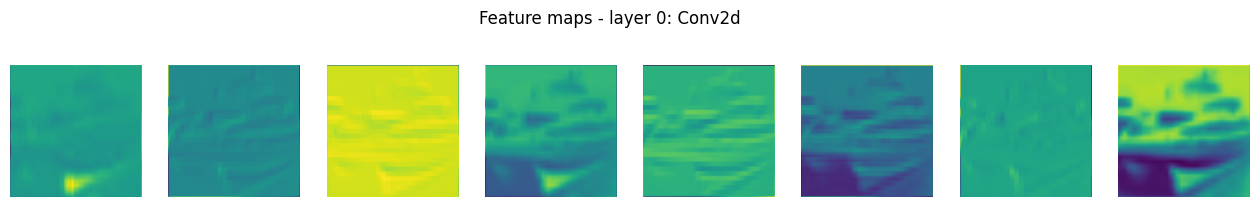

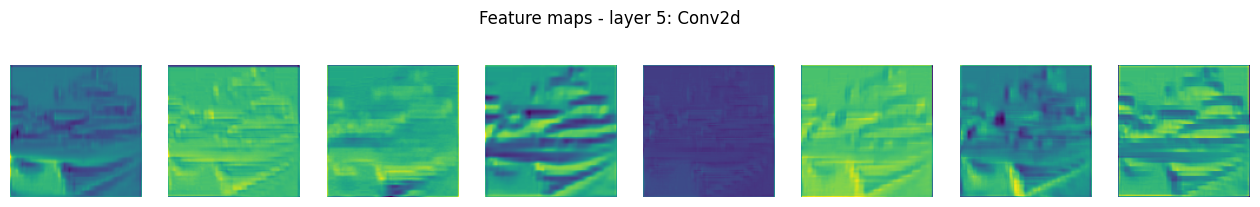

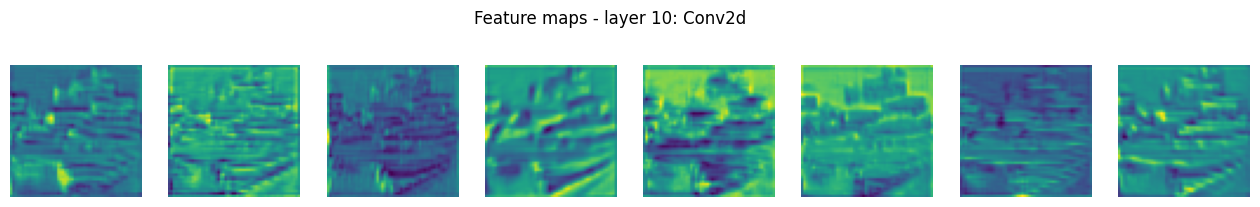

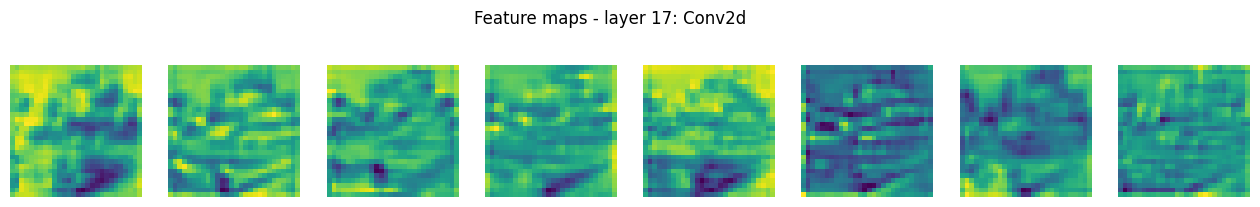

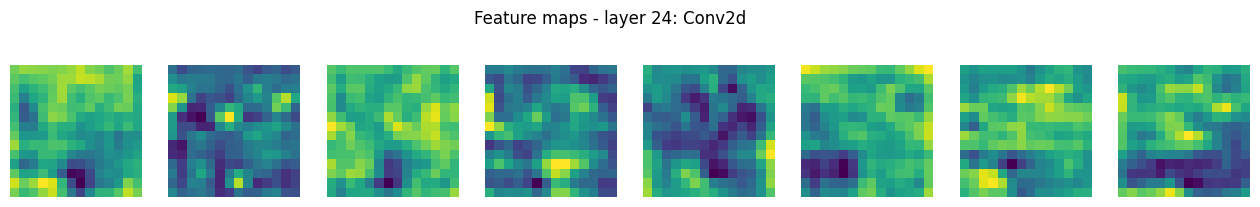

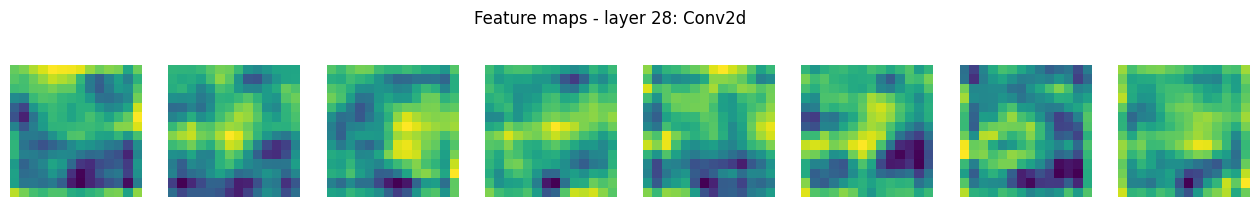

In [17]:
print("Pretrained VGG16 bez fine-tuningu")
adom.visualize_feature_maps(
    model=baseline_result["model"],
    image_tensor=image_tensor,
    layer_indices=FEATURE_MAP_LAYERS,
    max_maps=8,
)

VGG16 - trenowanie samego klasyfikatora


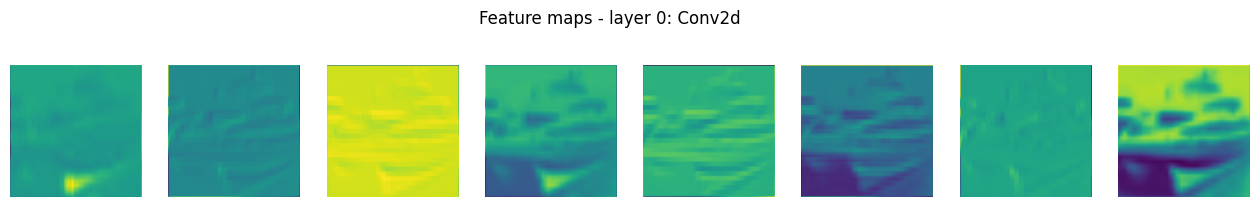

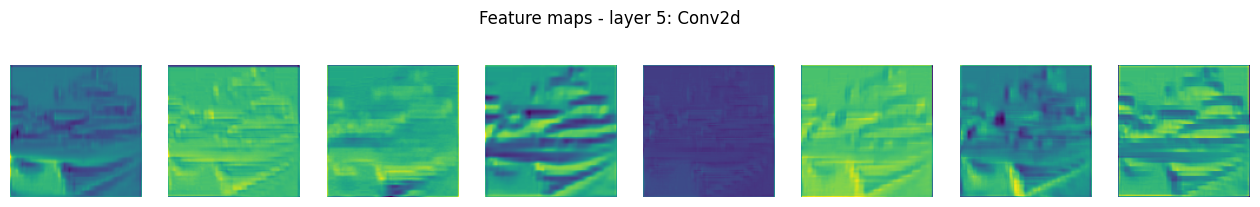

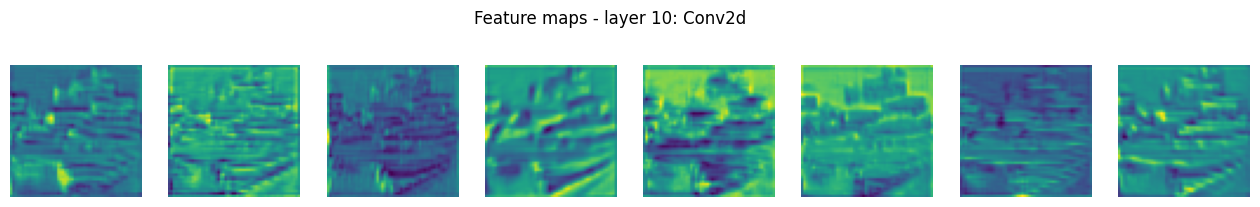

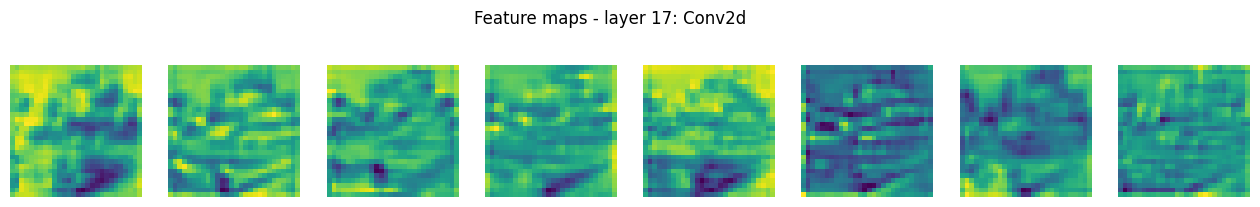

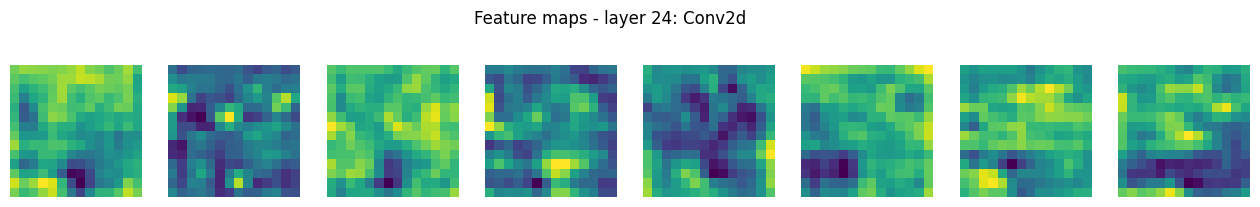

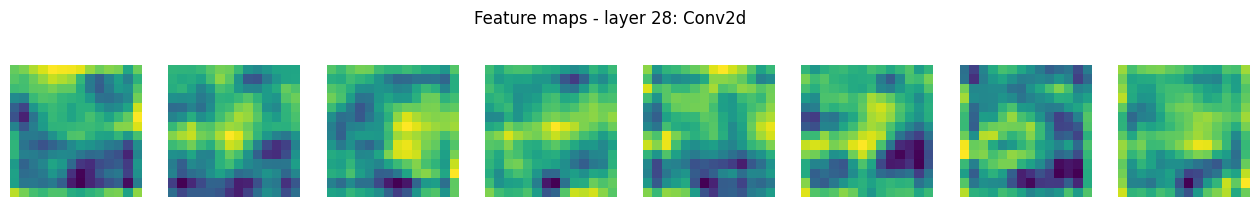

In [18]:
print("VGG16 - trenowanie samego klasyfikatora")
adom.visualize_feature_maps(
    model=classifier_only_result["model"],
    image_tensor=image_tensor,
    layer_indices=FEATURE_MAP_LAYERS,
    max_maps=8,
)

VGG16 - fine-tuning ostatnich warstw


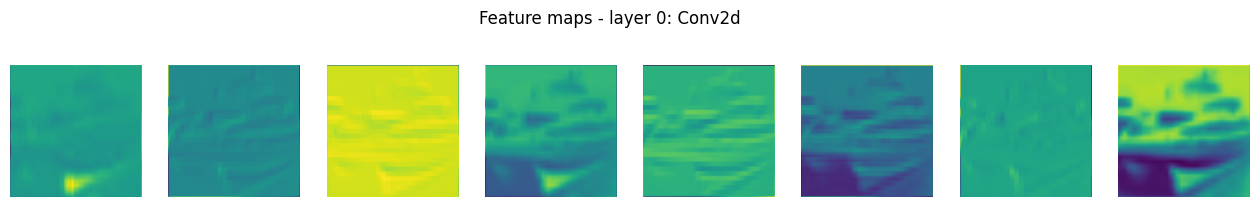

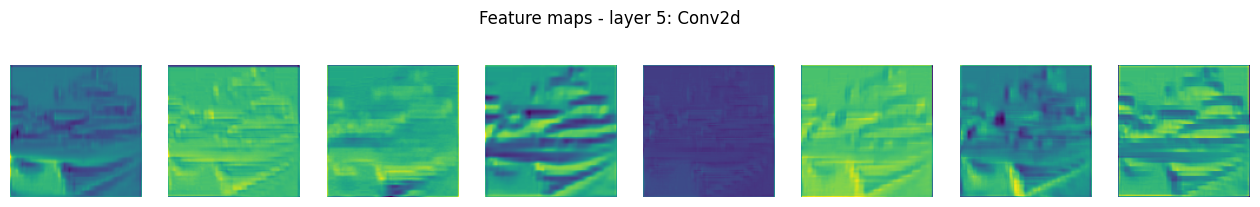

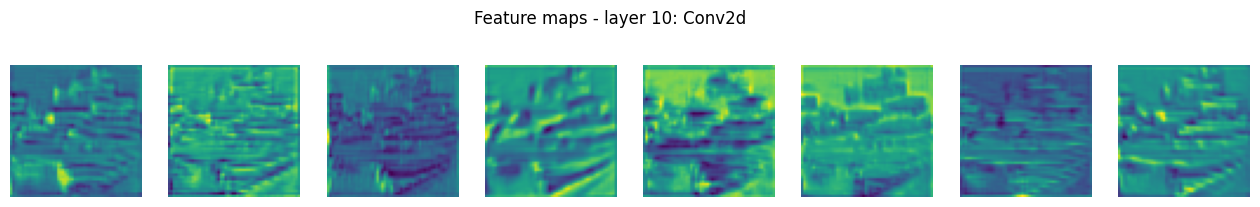

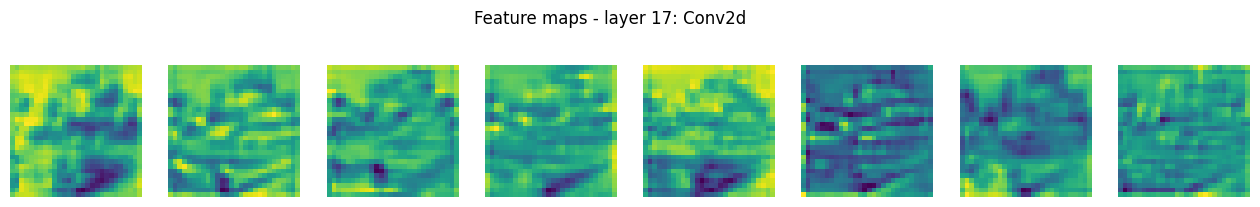

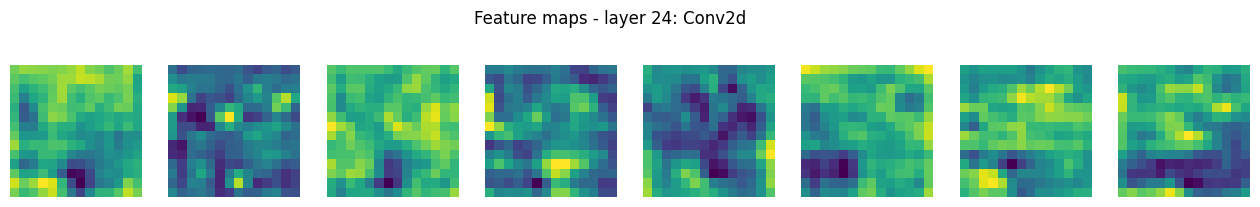

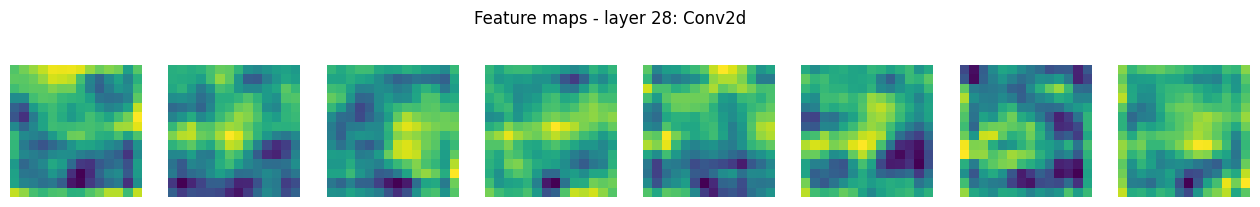

In [19]:
print("VGG16 - fine-tuning ostatnich warstw")
adom.visualize_feature_maps(
    model=last_layers_result["model"],
    image_tensor=image_tensor,
    layer_indices=FEATURE_MAP_LAYERS,
    max_maps=8,
)

VGG16 - pełny fine-tuning


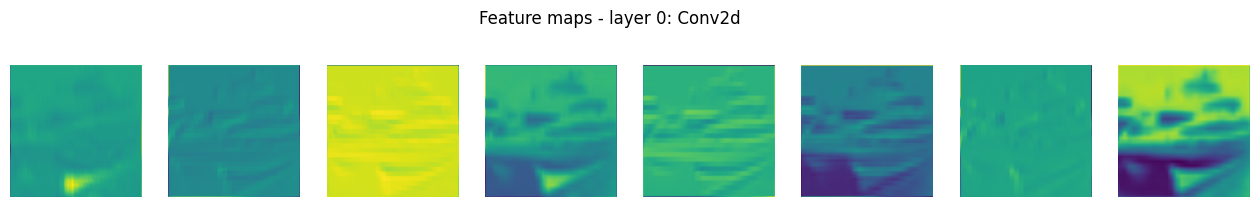

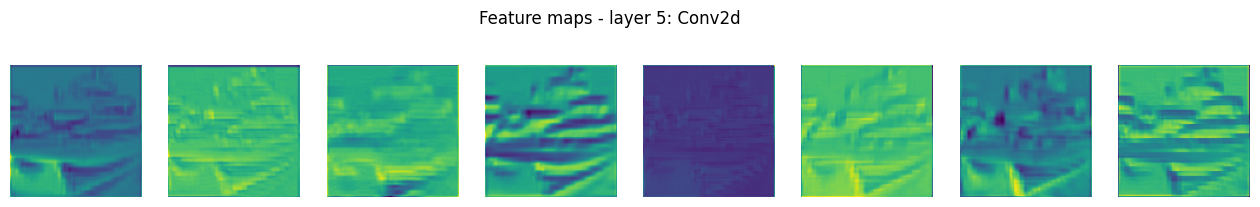

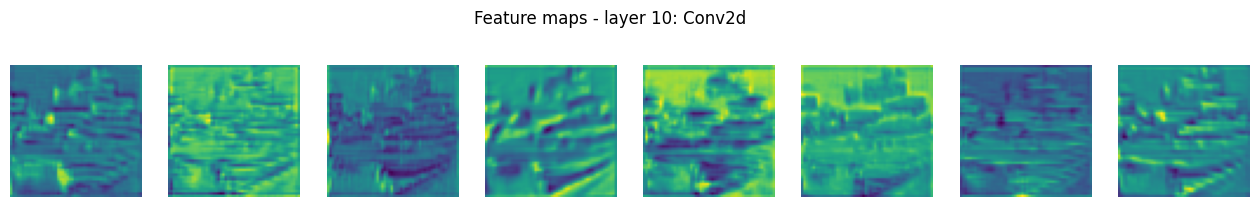

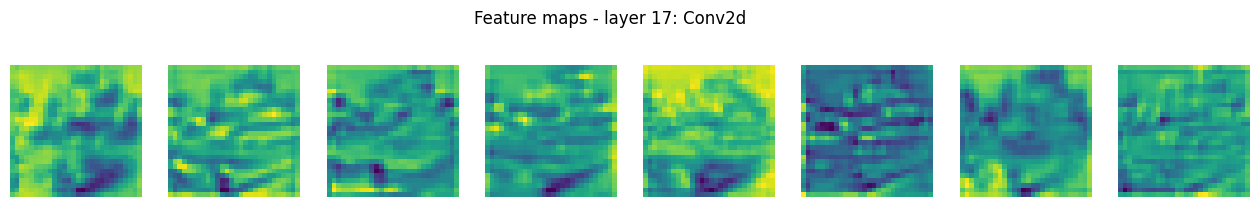

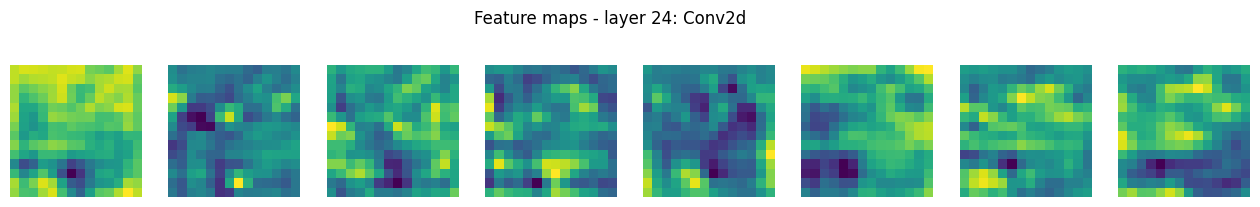

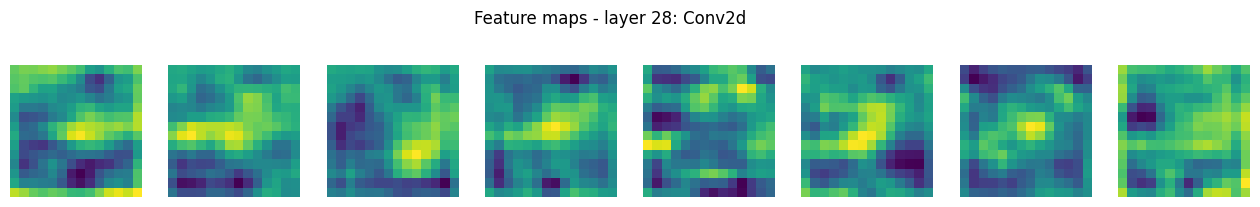

In [20]:
print("VGG16 - pełny fine-tuning")
adom.visualize_feature_maps(
    model=full_finetuning_result["model"],
    image_tensor=image_tensor,
    layer_indices=FEATURE_MAP_LAYERS,
    max_maps=8,
)

## Porównanie predykcji przed i po fine-tuningu

Na końcu sprawdzamy top-k predykcje dla wybranego obrazu testowego.

In [21]:
print("Prawdziwa klasa:", classes[label])

print("Pretrained bez fine-tuningu:")
for prediction in adom.predict_topk_classes(baseline_result["model"], image_tensor, classes, k=5):
    print(prediction)

print("Classifier only:")
for prediction in adom.predict_topk_classes(classifier_only_result["model"], image_tensor, classes, k=5):
    print(prediction)

print("Last layers fine-tuning:")
for prediction in adom.predict_topk_classes(last_layers_result["model"], image_tensor, classes, k=5):
    print(prediction)

print("Full fine-tuning:")
for prediction in adom.predict_topk_classes(full_finetuning_result["model"], image_tensor, classes, k=5):
    print(prediction)

Prawdziwa klasa: ship
Pretrained bez fine-tuningu:
{'rank': 1, 'class_id': 1, 'class_name': 'automobile', 'probability': 0.13348893821239471, 'probability_percent': 13.348893821239471}
{'rank': 2, 'class_id': 8, 'class_name': 'ship', 'probability': 0.12333259731531143, 'probability_percent': 12.333259731531143}
{'rank': 3, 'class_id': 9, 'class_name': 'truck', 'probability': 0.12269322574138641, 'probability_percent': 12.269322574138641}
{'rank': 4, 'class_id': 3, 'class_name': 'cat', 'probability': 0.11172191798686981, 'probability_percent': 11.172191798686981}
{'rank': 5, 'class_id': 0, 'class_name': 'airplane', 'probability': 0.10429173707962036, 'probability_percent': 10.429173707962036}
Classifier only:
{'rank': 1, 'class_id': 8, 'class_name': 'ship', 'probability': 0.9978048205375671, 'probability_percent': 99.78048205375671}
{'rank': 2, 'class_id': 0, 'class_name': 'airplane', 'probability': 0.0012477502459660172, 'probability_percent': 0.12477502459660172}
{'rank': 3, 'class_id

## Wnioski

W eksperymencie wykorzystano model VGG16 z wagami pretrained ImageNet. Ostatnia warstwa klasyfikatora została zastąpiona warstwą dopasowaną do 10 klas zbioru CIFAR-10. Porównano trzy strategie fine-tuningu: trenowanie samego klasyfikatora, fine-tuning ostatnich warstw konwolucyjnych oraz pełny fine-tuning całej sieci.

Wyniki pokazały, że samo wykorzystanie wag ImageNet bez dostrojenia klasyfikatora nie jest wystarczające. Model przed fine-tuningiem osiągnął jedynie 6,85% accuracy, ponieważ nowa warstwa klasyfikująca była losowo zainicjalizowana i nie była jeszcze dopasowana do klas CIFAR-10. Możemy to zaobserwować również po predykcjach dla przykładowego obrazu, gdzie poprawna klasa nie była wskazana jako najbardziej prawdopodobna, a wartości pewności były niskie i zbliżone do siebie.

Trenowanie klasyfikatora pozwoliło dopasować klasy CIFAR-10 do cech nauczonych na ImageNet, co znacznie poprawiło wyniki (osiągnięto 87,87% accuracy). Oznacza to, że cechy wyuczone wcześniej na ImageNet są w dużym stopniu przydatne również dla CIFAR-10, nawet bez modyfikowania części konwolucyjnej modelu.

Fine-tuning ostatnich warstw konwolucyjnych dał nieco lepszy wynik, ponieważ umożliwił modelowi dostosowanie głębszych reprezentacji do specyfiki CIFAR-10. Osiągnięto dzięki temu 88,23% accuracy, jednak niewielka poprawa sugeruje, że przy krótkim treningu i zastosowanym learning rate samo odmrożenie ostatniego bloku konwolucyjnego nie daje bardzo dużego zysku jakościowego.

Po pełnym fine-tuningu sieci uzyskalismy najlepsze wyniki. Model osiągnął 91,65% accuracy oraz najniższy test loss spośród badanych wariantów. Pełny fine-tuning zapewnił największą elastyczność, ponieważ wszystkie warstwy mogły dostosować swoje reprezentacje do zbioru CIFAR-10. Zysk jakościowy wiązał się jednak z największym kosztem obliczeniowym i pamięciowym.

Analizując czas treningu widzimy, że trening samego klasyfikatora trwał około 363 s, fine-tuning ostatnich warstw około 370 s, natomiast pełny fine-tuning około 4116 s. Oznacza to, że pełny fine-tuning był ponad 11 razy wolniejszy od pozostałych wariantów, mimo że poprawił accuracy względem trenowania samego klasyfikatora o jedynie ok. 3,78 punktu procentowego.

Podobną zależność można zaobserwować w użyciu pamięci GPU, gdzie odmrożenie większej liczby parametrów zwiększyło wyraźnie koszt pamięciowy (wzrost wykorzystywanej pamięci o nawet 4 GB). Wynika to z konieczności przechowywania większej liczby gradientów podczas treningu.

Analiza feature maps wskazała, że wczesne warstwy przechowują bardziej ogólne cechy obrazu, takie jak krawędzie, proste kształty i tekstury. Głębsze warstwy zawierają bardziej abstrakcyjne reprezentacje, które są silniej związane z zadaniem klasyfikacji. Różnice pomiędzy wariantami fine-tuningu są szczególnie widoczne właśnie w głębszych warstwach, ponieważ to one odpowiadają za bardziej semantyczną interpretację obrazu. 

Podsumowując, eksperyment pokazał, że pełny fine-tuning najbardziej poprawia jakość klasyfikacji, jednak wiąże się on z największym kosztem obliczeniowym i pamięciowym. Pozostałe omawiane warianty trenowania są znacznie szybsze, jak i wymagają znacznie mniej pamięci. Są więc dobrym kompromisem w sytuacji ograniczonych zasobów.